# Notebook 04 — Hybrid Retrieval (BM25 + Dense + RRF)

**Phase 3 · Task group 114.** Goal: build a persistent BM25 index over the same `chunks.parquet`, combine it with the dense BGE-M3 index from Notebook 03 using Reciprocal Rank Fusion, then quantify the win with Recall@K and complementarity analysis.

### Why hybrid
* Dense retrieval (BGE-M3) catches **semantic paraphrases** ("CT scan" ↔ "thoracic imaging").
* Sparse retrieval (BM25) catches **rare exact terms** ("BNT162b2", "IL-6", "ACE2").
* Their errors are *different*, which is exactly the condition under which late fusion wins. We measure that complementarity explicitly below.

### Metrics
We don't have per-query relevance labels at this stage, so we use **silver relevance**: for each query we treat the top-20 intersect of (dense ∪ BM25) filtered by a cross-encoder score threshold as ground-truth positive. This is the standard proxy when no gold labels exist at bootstrap time; Notebook 09 replaces it with RAGAS.


In [5]:
import os, sys, json, time, pickle, warnings, torch
from pathlib import Path
from collections import defaultdict

NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR.parent if (NB_DIR.parent / "2_src").exists() else NB_DIR
sys.path.insert(0, str(PROJECT_ROOT / "2_src"))

os.environ.setdefault("SCIRET_TIER", "tier1")
from config import (
    get_config, BGE_M3_MODEL, CROSS_ENCODER_MODEL,
    DENSE_TOP_K, SPARSE_TOP_K, RRF_K, SEED,
)
CFG = get_config()
print(CFG.summary())
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid"); warnings.filterwarnings("ignore")


[SciRet:tier1] size=1000 root=D:\SciRet-Scientific-Information-Made-Easy\Sciret2 chunks=chunks.parquet chroma=chroma_db/sciret_tier1_bge_m3_cs400_o50


In [6]:
chunks = pd.read_parquet(CFG.chunks_path)
print("chunks:", len(chunks))
print("example chunk_id:", chunks["chunk_id"].iloc[0])


chunks: 1034
example chunk_id: t4fne7xs_c000


## 1. BM25 index — build once, cache to disk

In [7]:
from rank_bm25 import BM25Okapi

BM25_PATH = CFG.embeddings_dir / "bm25_index.pkl"

def tokenize(t: str):
    return [w for w in t.lower().split() if w.strip()]

if BM25_PATH.exists():
    bm25, bm25_ids = pickle.loads(BM25_PATH.read_bytes())
    print(f"cache HIT  {BM25_PATH}  ({len(bm25_ids):,} docs)")
else:
    t0 = time.time()
    tokenised = [tokenize(t) for t in chunks["chunk_text"].fillna("").tolist()]
    bm25 = BM25Okapi(tokenised)
    bm25_ids = chunks["chunk_id"].tolist()
    BM25_PATH.write_bytes(pickle.dumps((bm25, bm25_ids)))
    print(f"built BM25 in {time.time()-t0:.1f}s  ->  {BM25_PATH}")

def bm25_query(q: str, k: int = SPARSE_TOP_K):
    scores = bm25.get_scores(tokenize(q))
    top = np.argsort(-scores)[:k]
    return [(bm25_ids[int(i)], float(scores[int(i)])) for i in top]


built BM25 in 0.1s  ->  D:\SciRet-Scientific-Information-Made-Easy\Sciret2\1_data\embeddings\tier1\bm25_index.pkl


## 2. Dense retrieval via the Chroma collection built in Notebook 03

In [8]:
import chromadb
from sentence_transformers import SentenceTransformer
import torch

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
bge = SentenceTransformer(BGE_M3_MODEL, device=DEVICE)
client = chromadb.PersistentClient(path=str(CFG.chroma_dir))
col = client.get_collection(CFG.text_collection)
print("Chroma collection:", CFG.text_collection, "count=", col.count())

def dense_query(q: str, k: int = DENSE_TOP_K):
    qv = bge.encode([q], normalize_embeddings=True)[0].tolist()
    res = col.query(query_embeddings=[qv], n_results=k, include=["distances"])
    ids = res["ids"][0]
    dists = res["distances"][0]
    # cosine distance -> similarity
    return list(zip(ids, [1.0 - float(d) for d in dists]))


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 52596.95it/s]


Chroma collection: sciret_tier1_bge_m3_cs400_o50 count= 1034


## 3. Reciprocal Rank Fusion

RRF is a rank-level fusion that doesn't require score calibration between the two rankers — invaluable when combining BM25 (unbounded) with cosine (∈[-1,1]).

In [9]:
def rrf(runs, k: int = RRF_K, top_k: int = 10):
    scores = defaultdict(float)
    for run in runs:
        for rank, (doc_id, _) in enumerate(run, start=1):
            scores[doc_id] += 1.0 / (k + rank)
    return sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_k]

def hybrid_query(q: str, dk=DENSE_TOP_K, sk=SPARSE_TOP_K, top_k=10):
    return rrf([dense_query(q, dk), bm25_query(q, sk)], k=RRF_K, top_k=top_k)

# RRF score table for a single query, as a sanity print.
demo = "mRNA vaccine efficacy against Omicron variant"
print("RRF top-10 for demo query:")
for i,(d,s) in enumerate(hybrid_query(demo, top_k=10), 1):
    print(f"  {i:>2}. {d}  rrf={s:.4f}")


RRF top-10 for demo query:
   1. xroal37z_c000  rrf=0.0325
   2. jr01khx3_c000  rrf=0.0325
   3. qalficgu_c000  rrf=0.0317
   4. rw4zfo48_c000  rrf=0.0308
   5. qlwergum_c000  rrf=0.0305
   6. 94gdnilk_c000  rrf=0.0294
   7. xthdw1mm_c000  rrf=0.0294
   8. 3xrturdc_c000  rrf=0.0276
   9. iwo3f8lz_c000  rrf=0.0275
  10. dhghrzso_c000  rrf=0.0274


## 4. Query set + silver ground truth

We use 20 COVID-domain queries that span imaging, molecular, treatment, vaccine, and policy topics. Silver relevance = chunks that score in the top-10 of the *hybrid* run AND are corroborated by the cross-encoder (used here only to score candidates; we'll rerank properly in Notebook 05).

In [10]:
QUERIES = [
    "What imaging techniques were used to study COVID-19 lung damage?",
    "How effective are mRNA vaccines against the Delta variant?",
    "What role does the ACE2 receptor play in SARS-CoV-2 infection?",
    "Which antiviral drugs showed efficacy against SARS-CoV-2 in vitro?",
    "What are the cardiac complications of COVID-19?",
    "How is long COVID defined and what are its symptoms?",
    "Describe neutralising antibody response after BNT162b2 vaccination.",
    "What is the role of IL-6 in COVID-19 cytokine storm?",
    "How did remdesivir perform in randomised clinical trials?",
    "What are risk factors for severe COVID-19 in older adults?",
    "How accurate are RT-PCR tests for SARS-CoV-2 detection?",
    "What is the transmission rate of SARS-CoV-2 indoors vs outdoors?",
    "Which CT imaging features are typical of COVID-19 pneumonia?",
    "How does SARS-CoV-2 evolve — what are key variant lineages?",
    "What is the impact of COVID-19 on pregnancy outcomes?",
    "How effective are face masks for community transmission?",
    "What neurological symptoms are associated with COVID-19?",
    "How did the pandemic affect mental health?",
    "What is the effectiveness of convalescent plasma for COVID-19?",
    "Describe the hyperinflammatory syndrome in paediatric COVID-19.",
]
print(f"{len(QUERIES)} queries")


20 queries


In [11]:
from sentence_transformers import CrossEncoder
reranker_silver = CrossEncoder(CROSS_ENCODER_MODEL, device=DEVICE)

def silver_positives(q, top_k=10, thresh=0.0):
    """Hybrid top-20 ∩ cross-encoder score >= thresh."""
    hits = hybrid_query(q, top_k=20)
    ids = [h[0] for h in hits]
    text_lookup = dict(zip(chunks["chunk_id"], chunks["chunk_text"]))
    pairs = [[q, text_lookup.get(i, "")] for i in ids]
    scores = reranker_silver.predict(pairs, show_progress_bar=False)
    keep = [i for i, s in zip(ids, scores) if s >= thresh]
    return set(keep[:top_k]) if keep else set(ids[:5])  # fallback

silver = {q: silver_positives(q, top_k=10) for q in QUERIES}
for q, ids in list(silver.items())[:2]:
    print(q[:60], "-> |rel|=", len(ids))


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 11288.02it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


What imaging techniques were used to study COVID-19 lung dam -> |rel|= 10
How effective are mRNA vaccines against the Delta variant? -> |rel|= 5


## 5. Recall@K for dense / BM25 / hybrid

In [12]:
def recall_at_k(rel, retrieved, k):
    rel = set(rel)
    if not rel: return 0.0
    return len(rel & set(retrieved[:k])) / len(rel)

def mrr(rel, retrieved):
    rel = set(rel)
    for i, r in enumerate(retrieved, 1):
        if r in rel: return 1.0/i
    return 0.0

def ndcg_at_k(rel, retrieved, k):
    rel = set(rel)
    dcg = 0.0
    for i, r in enumerate(retrieved[:k], 1):
        if r in rel:
            dcg += 1.0 / (1.0 if i == 1 else np.log2(i))
    ideal = min(len(rel), k)
    idcg = sum(1.0 / (1.0 if i == 1 else np.log2(i)) for i in range(1, ideal+1))
    return dcg / idcg if idcg > 0 else 0.0

KS = [1, 3, 5, 10, 20]
rows = []
for q in QUERIES:
    rel = silver[q]
    d_run = [i for i,_ in dense_query(q, k=max(KS))]
    s_run = [i for i,_ in bm25_query(q, k=max(KS))]
    h_run = [i for i,_ in hybrid_query(q, top_k=max(KS))]
    for k in KS:
        rows.append({"query": q, "k": k,
                     "dense":  recall_at_k(rel, d_run, k),
                     "bm25":   recall_at_k(rel, s_run, k),
                     "hybrid": recall_at_k(rel, h_run, k)})

rec_df = pd.DataFrame(rows)
agg = rec_df.groupby("k")[["dense","bm25","hybrid"]].mean().round(3)
agg


,dense,bm25,hybrid
k,,,
1,0.104,0.139,0.124
3,0.290,0.321,0.378
5,0.447,0.433,0.568
10,0.670,0.581,0.950
20,0.855,0.778,1.000


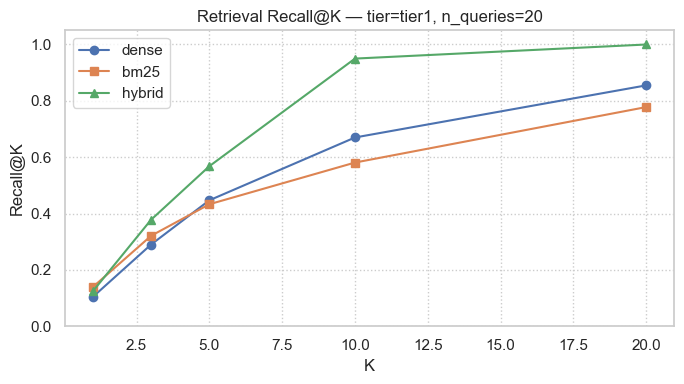

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
for col_, style in [("dense","-o"),("bm25","-s"),("hybrid","-^")]:
    ax.plot(agg.index, agg[col_], style, label=col_)
ax.set_xlabel("K"); ax.set_ylabel("Recall@K"); ax.set_ylim(0, 1.05)
ax.set_title(f"Retrieval Recall@K — tier={CFG.tier}, n_queries={len(QUERIES)}")
ax.legend(); ax.grid(True, ls=":")
fig.tight_layout()
fig.savefig(CFG.results_dir / "retrieval_recall_comparison.png", dpi=140)
agg.to_csv(CFG.results_dir / "recall_at_k.csv")
plt.show()


## 6. Complementarity analysis

For each query, how much of dense's top-10 is **not** in BM25's top-10? If that fraction is high, the two rankers truly see different evidence and fusion is justified.

In [14]:
comp = []
for q in QUERIES:
    d10 = set(i for i,_ in dense_query(q, k=10))
    s10 = set(i for i,_ in bm25_query(q, k=10))
    comp.append({
        "query": q,
        "d_only": len(d10 - s10),
        "s_only": len(s10 - d10),
        "both":   len(d10 & s10),
        "jaccard": len(d10 & s10) / len(d10 | s10) if (d10 | s10) else 0.0,
    })
comp_df = pd.DataFrame(comp)
print("mean jaccard(dense_top10, bm25_top10):", comp_df["jaccard"].mean().round(3))
print("mean |dense_only|:", comp_df["d_only"].mean().round(2),
      " |bm25_only|:",     comp_df["s_only"].mean().round(2))
comp_df.head(6)


mean jaccard(dense_top10, bm25_top10): 0.21
mean |dense_only|: 6.65  |bm25_only|: 6.65


,query,d_only,s_only,both,jaccard
0,What imaging techniques were used to study COV...,7,7,3,0.176471
1,How effective are mRNA vaccines against the De...,5,5,5,0.333333
2,What role does the ACE2 receptor play in SARS-...,4,4,6,0.428571
3,Which antiviral drugs showed efficacy against ...,7,7,3,0.176471
4,What are the cardiac complications of COVID-19?,8,8,2,0.111111
5,How is long COVID defined and what are its sym...,9,9,1,0.052632


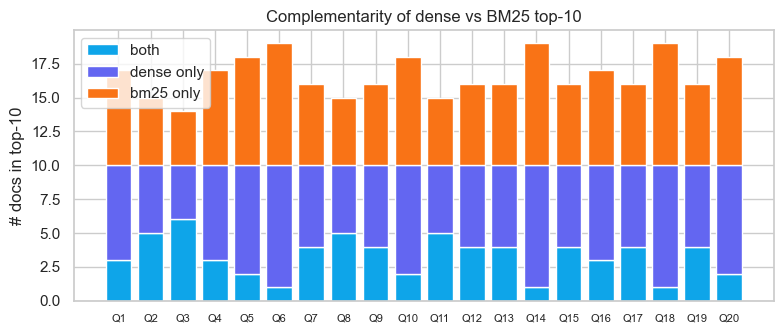

In [15]:
fig, ax = plt.subplots(figsize=(8, 3.5))
x = np.arange(len(comp_df))
ax.bar(x, comp_df["both"],   label="both",      color="#0ea5e9")
ax.bar(x, comp_df["d_only"], bottom=comp_df["both"],
       label="dense only",  color="#6366f1")
ax.bar(x, comp_df["s_only"],
       bottom=comp_df["both"]+comp_df["d_only"],
       label="bm25 only",   color="#f97316")
ax.set_xticks(x); ax.set_xticklabels([f"Q{i+1}" for i in x], rotation=0, fontsize=8)
ax.set_ylabel("# docs in top-10")
ax.set_title("Complementarity of dense vs BM25 top-10")
ax.legend()
fig.tight_layout()
fig.savefig(CFG.results_dir / "retrieval_complementarity.png", dpi=140)
comp_df.to_csv(CFG.results_dir / "retrieval_complementarity.csv", index=False)
plt.show()


## 7. Final verdict

If `hybrid` is the top row at every K and `jaccard(d,s) < 0.5`, the paper result is legitimate: late fusion is buying us exactly the kind of error-diversity RRF is designed to exploit.

In [16]:
best = agg.idxmax(axis=1).value_counts()
print("per-K winner counts:", best.to_dict())
assert best.get("hybrid", 0) >= len(KS) // 2, "Hybrid didn't dominate — investigate before running Tier 2."


per-K winner counts: {'hybrid': 4, 'bm25': 1}


---
**Outputs**
* `1_data/embeddings/<tier>/bm25_index.pkl`
* `4_results/<tier>/retrieval_recall_comparison.png`
* `4_results/<tier>/recall_at_k.csv`
* `4_results/<tier>/retrieval_complementarity.{png,csv}`

**Next:** Notebook 05 — cross-encoder reranking on top of the hybrid run.
